# IMPORT LIBRARY

Pada tahap awal, dilakukan import library yang digunakan dalam proses analisis data dan pembangunan model clustering.

Library yang digunakan meliputi:
- pandas dan numpy untuk manipulasi data
- matplotlib dan seaborn untuk visualisasi data
- sklearn.preprocessing untuk encoding dan scaling
- sklearn.cluster untuk algoritma K-Means
- sklearn.metrics untuk evaluasi menggunakan Silhouette Score
- sklearn.decomposition untuk reduksi dimensi menggunakan PCA
- joblib untuk menyimpan model

In [45]:
# ==============================
# IMPORT LIBRARY
# ==============================

# Ignore warning
import warnings
warnings.filterwarnings('ignore')

# ==============================
# Data Manipulation
# ==============================
import pandas as pd
import numpy as np

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# Setting tampilan
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')
plt.rcParams['figure.autolayout'] = True

# ==============================
# Preprocessing
# ==============================
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ==============================
# Clustering
# ==============================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==============================
# Dimensionality Reduction
# ==============================
from sklearn.decomposition import PCA

# ==============================
# Model Saving
# ==============================
import joblib
from google.colab import files

# LOAD DATA & INITIAL INSPECTION

In [34]:
# ==============================
# LOAD DATA
# ==============================

sheet_id = "1-x8hz_KfX4qg-GDp6i4WZzNG9pp7b0KaEO_pJwFGrwU"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

df = pd.read_csv(url)

# SIMPAN DATA ASLI
df_original = df.copy()

# ==============================
# PREVIEW DATA
# ==============================

# Menampilkan 5 baris pertama
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


In [3]:
# ==============================
# DATA OVERVIEW
# ==============================

# Informasi dataset
df.info()

# Statistik deskriptif
df.describe()

# Shape dataset
print("Shape dataset:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [4]:
# ==============================
# DATA TYPES CHECK
# ==============================

df.dtypes

,0
TransactionID,object
AccountID,object
TransactionAmount,float64
PreviousTransactionDate,object
TransactionType,object
Location,object
DeviceID,object
IP Address,object
MerchantID,object
Channel,object


In [5]:
# Jumlah fitur numerik & kategorikal
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Jumlah fitur numerik:", len(num_cols))
print("Jumlah fitur kategorikal:", len(cat_cols))

Jumlah fitur numerik: 5
Jumlah fitur kategorikal: 11


Data Understanding

Dataset yang digunakan dalam penelitian ini diambil dari Google Spreadsheet dan terdiri dari sejumlah fitur yang merepresentasikan informasi transaksi pengguna.

Berdasarkan hasil eksplorasi awal:

- Dataset memiliki ukuran sebesar 2537 baris dan 16 kolom.
- Informasi tipe data diperoleh menggunakan fungsi `.info()`

Analisis statistik deskriptif menggunakan `.describe()` menunjukkan bahwa:
- Nilai minimum, maksimum, dan rata-rata pada fitur numerik bervariasi
- Beberapa fitur memiliki potensi outlier, terlihat dari perbedaan signifikan antara nilai maksimum dan rata-rata

Pengecekan tipe data menggunakan `.dtypes` menunjukkan bahwa dataset terdiri dari kombinasi data numerik dan kategorikal yang perlu diproses lebih lanjut sebelum digunakan dalam modeling.

# EXPLORATORY DATA ANALYSIS (EDA)

## Korelasi Antar Fitur

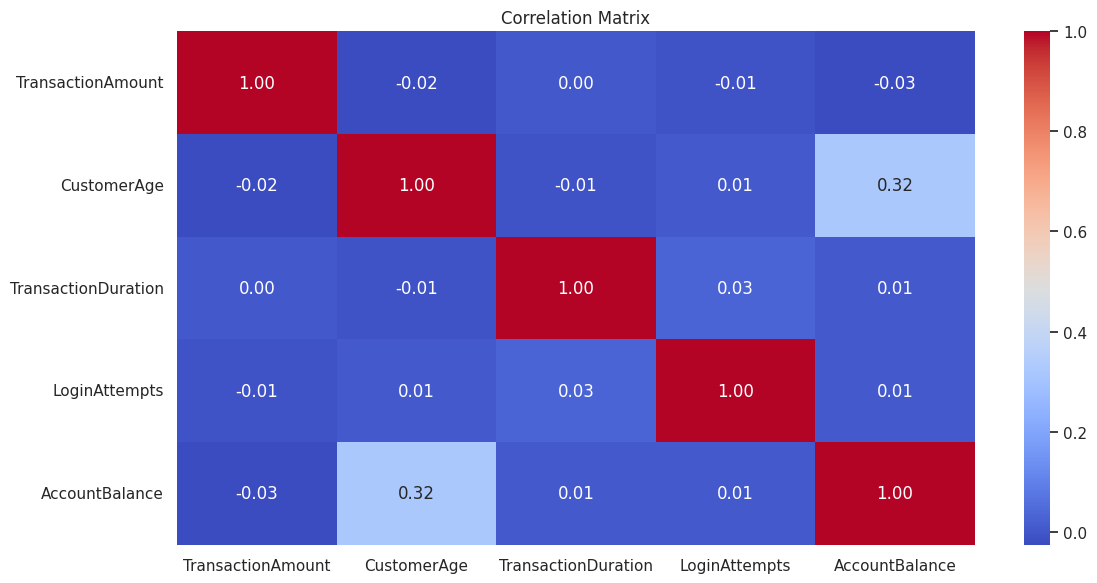

In [6]:
# ==============================
# CORRELATION MATRIX
# ==============================

plt.figure(figsize=(12,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

### Analisis Korelasi

Analisis korelasi dilakukan untuk mengetahui hubungan antar fitur numerik dalam dataset.

Berdasarkan heatmap korelasi:
- Beberapa fitur menunjukkan korelasi positif/negatif yang cukup kuat
- Fitur dengan korelasi tinggi berpotensi memberikan informasi yang redundan

Namun, karena metode clustering K-Means berbasis jarak, seluruh fitur tetap dipertahankan untuk menjaga informasi distribusi data.

## Distribusi Fitur Numerik

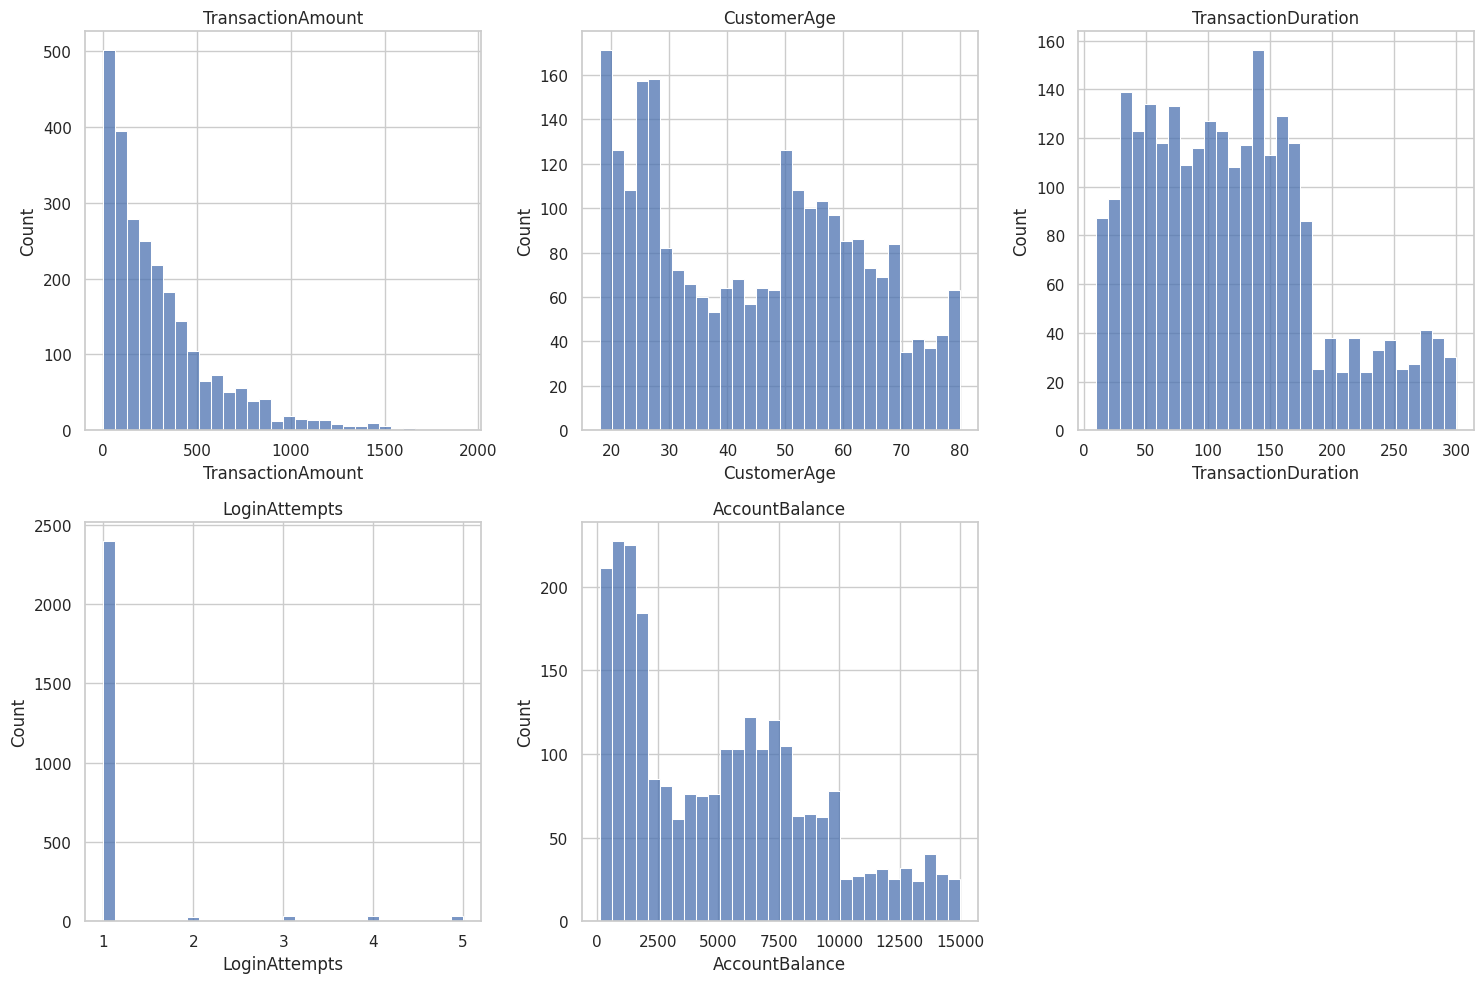

In [7]:
# ==============================
# HISTOGRAM NUMERICAL FEATURES
# ==============================

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

### Distribusi Fitur Numerik

Distribusi fitur numerik divisualisasikan menggunakan histogram.

Hasil menunjukkan bahwa:
- Beberapa fitur memiliki distribusi yang tidak normal (skewed)
- Terdapat indikasi outlier pada beberapa fitur dengan nilai ekstrem

Hal ini menjadi dasar dilakukannya proses handling outlier pada tahap preprocessing.

## Distribusi Fitur Kategorikal

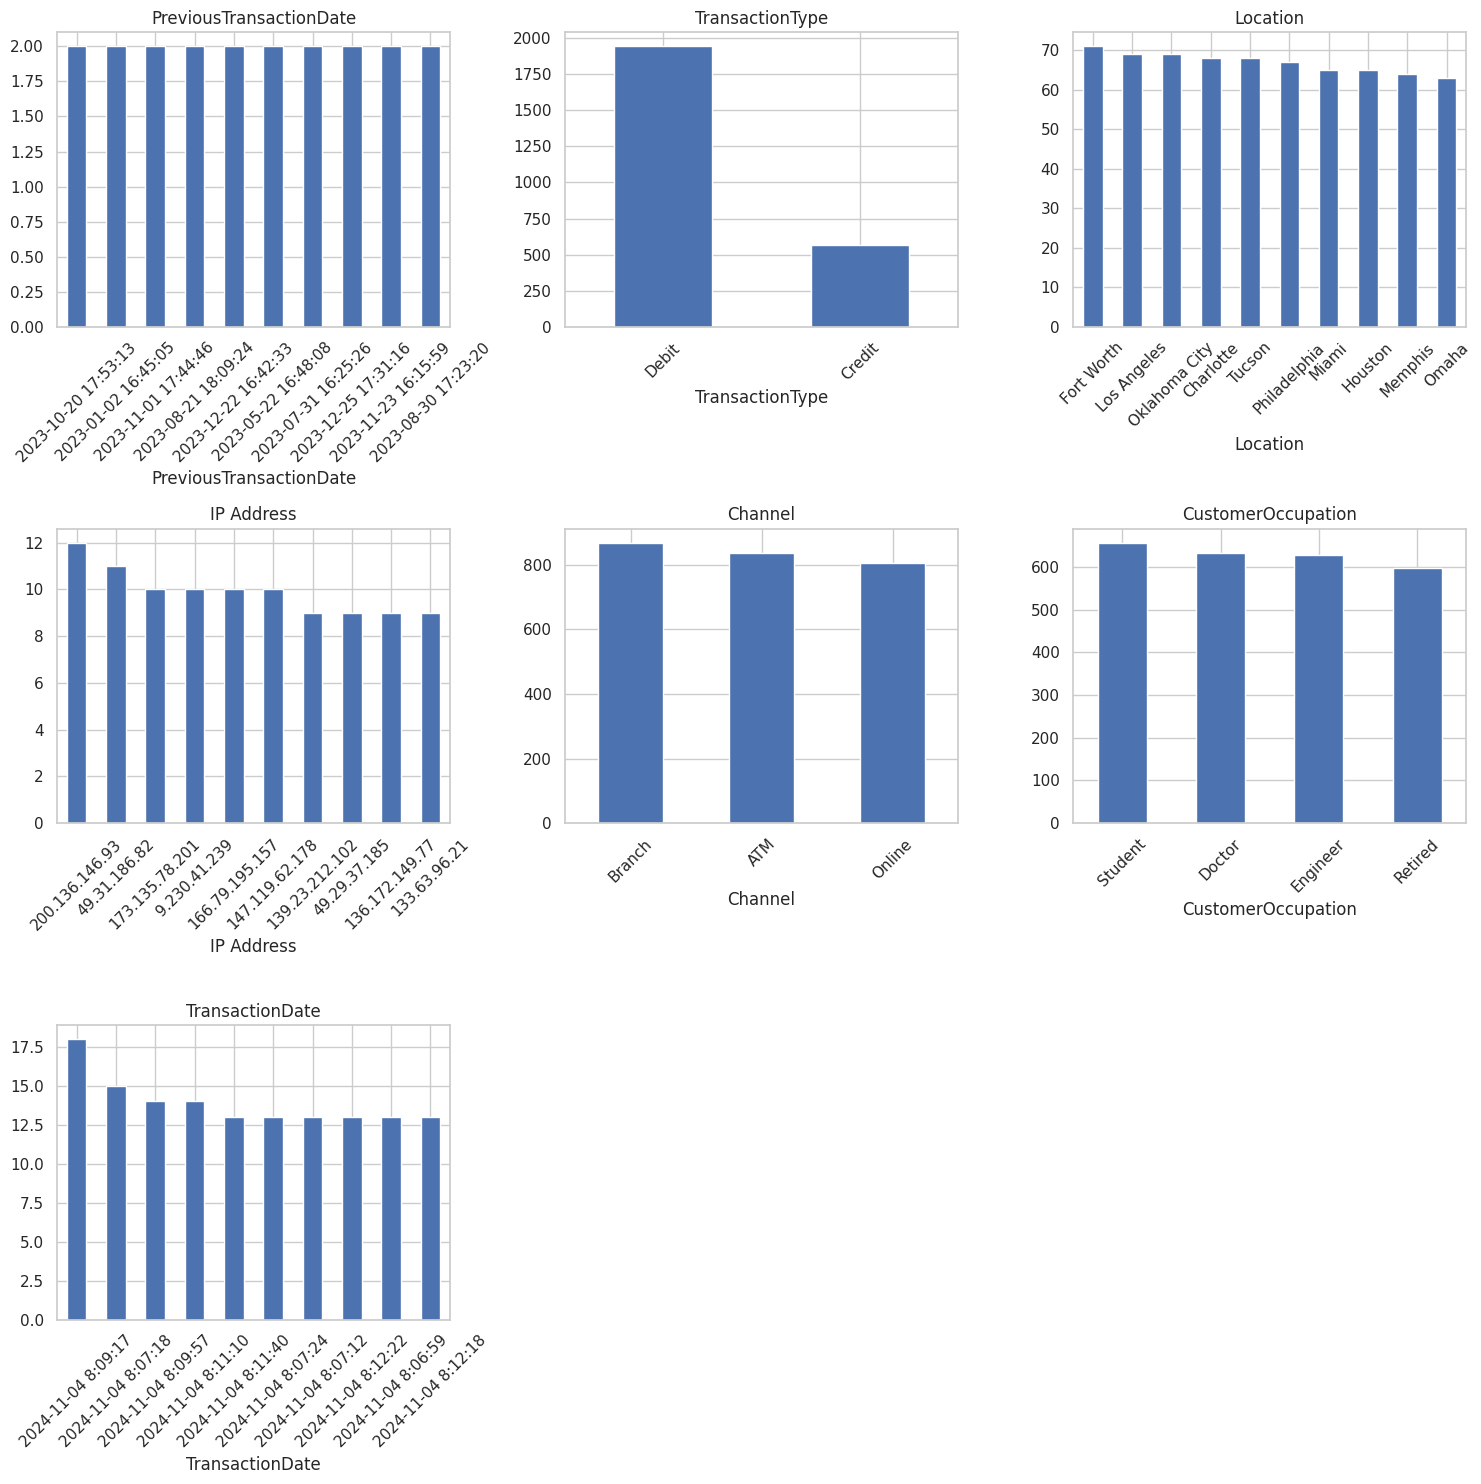

In [8]:
# ==============================
# CATEGORICAL DISTRIBUTION
# ==============================

id_columns = ['TransactionID', 'AccountID', 'DeviceID', 'IPAddress', 'MerchantID']

cat_cols = [
    col for col in df.select_dtypes(include='object').columns
    if col not in id_columns
]

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    df[col].value_counts().nlargest(10).plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Distribusi fitur kategorikal divisualisasikan menggunakan bar chart.

Hasil menunjukkan bahwa:
- Beberapa kategori memiliki distribusi yang tidak seimbang
- Terdapat kategori dominan pada beberapa fitur

Hal ini perlu diperhatikan karena dapat mempengaruhi hasil clustering setelah proses encoding.

### Insight Awal

Berdasarkan hasil eksplorasi data:

- Dataset mengandung kombinasi fitur numerik dan kategorikal yang cukup kompleks
- Terdapat indikasi outlier pada beberapa fitur numerik
- Distribusi kategori yang tidak merata dapat mempengaruhi hasil encoding

Oleh karena itu, diperlukan proses preprocessing yang mencakup:
- pembersihan data
- encoding fitur kategorikal
- scaling fitur numerik
- penanganan outlier

agar data siap digunakan dalam proses clustering.

# DATA CLEANING & PREPROCESSING

## Missing Value & Duplicate

In [9]:
# ==============================
# CHECK MISSING VALUE
# ==============================

df.isnull().sum().sort_values(ascending=False)

# Handling missing value
df = df.dropna()


# ==============================
# CHECK DUPLICATE
# ==============================

df.duplicated().sum()

# Remove duplicate
df = df.drop_duplicates()

### Penanganan Missing Value
Pengecekan missing value dilakukan menggunakan fungsi `isnull().sum()`.

Hasil menunjukkan bahwa terdapat missing value pada beberapa kolom, sehingga dilakukan penghapusan data menggunakan metode drop untuk menjaga konsistensi dataset.

### Penanganan Data Duplikat
Pengecekan data duplikat dilakukan menggunakan `duplicated().sum()`.

Data duplikat yang ditemukan kemudian dihapus untuk menghindari bias dalam proses analisis.

## Drop Kolom Tidak Relevan

In [10]:
# ==============================
# DROP IRRELEVANT COLUMNS
# ==============================

drop_cols = [
    "TransactionID",
    "AccountID",
    "DeviceID",
    "IPAddress",
    "MerchantID",
    "TransactionDate"
]

df = df.drop(columns=drop_cols, errors='ignore')

Beberapa kolom dihapus karena tidak relevan terhadap proses clustering, yaitu:
- TransactionID
- AccountID
- DeviceID
- IPAddress
- MerchantID
- TransactionDate

Kolom tersebut bersifat identifier atau tidak memiliki kontribusi langsung terhadap pola data, sehingga dapat mengganggu proses clustering berbasis jarak.

## Encoding Kategorikal

In [39]:
# ==============================
# ENCODING
# ==============================

encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

Fitur kategorikal dikonversi menjadi numerik menggunakan LabelEncoder.

Langkah ini diperlukan karena algoritma K-Means hanya dapat memproses data numerik. Setiap kategori diubah menjadi representasi numerik agar dapat digunakan dalam perhitungan jarak.

## Feature Scaling

In [12]:
# ==============================
# SCALING
# ==============================

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

Dilakukan feature scaling menggunakan StandardScaler.

Proses ini bertujuan untuk menyamakan skala antar fitur, karena algoritma K-Means berbasis jarak Euclidean yang sensitif terhadap perbedaan skala data.

## Handling Outlier

In [13]:
# ==============================
# OUTLIER HANDLING (IQR METHOD)
# ==============================

Q1 = df_scaled.quantile(0.25)
Q3 = df_scaled.quantile(0.75)
IQR = Q3 - Q1

df_scaled = df_scaled[
    ~((df_scaled < (Q1 - 1.5 * IQR)) | (df_scaled > (Q3 + 1.5 * IQR))).any(axis=1)
].reset_index(drop=True)

Outlier ditangani menggunakan metode Interquartile Range (IQR).

Data yang berada di luar rentang:
Q1 - 1.5 * IQR dan Q3 + 1.5 * IQR dihapus untuk mengurangi pengaruh nilai ekstrem terhadap proses clustering.

## Binning

In [14]:
# ==============================
# BINNING
# ==============================

df_scaled['Amount_bin'] = pd.qcut(
    df_scaled['TransactionAmount'],
    q=4,
    labels=False
)

Dilakukan binning pada fitur TransactionAmount menggunakan metode quantile (qcut) menjadi 4 kelompok.

Tujuan:
Untuk mengelompokkan nilai transaksi ke dalam kategori tertentu sehingga dapat membantu proses analisis pola.

## Validasi Dataset

In [15]:
# ==============================
# FINAL CHECK
# ==============================

print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

df_scaled.describe()

print("Shape setelah cleaning:", df.shape)
print("Shape setelah scaling:", df_scaled.shape)

Missing values:
 TransactionAmount          0
PreviousTransactionDate    0
TransactionType            0
Location                   0
IP Address                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
dtype: int64
Duplicate rows: 0
Shape setelah cleaning: (2135, 11)
Shape setelah scaling: (1501, 12)


In [67]:
df_scaled.to_csv("data_clustering.csv", index=False)
files.download("data_clustering.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Setelah preprocessing:
- Tidak terdapat missing value
- Tidak terdapat data duplikat
- Seluruh fitur telah dalam bentuk numerik
- Data telah melalui proses scaling

Dataset siap digunakan untuk proses clustering.

# CLUSTERING MODELING

## Reduksi Dimensi dengan PCA

In [16]:
# ==============================
# PCA (DIMENSION REDUCTION)
# ==============================

df_cluster = df_scaled.drop('Target', axis=1, errors='ignore')

pca = PCA(n_components=3, random_state=42)
df_pca = pca.fit_transform(df_cluster)

df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2', 'PC3'])

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.19851359 0.17551559 0.10773884]
Total Explained Variance: 0.481768010032259


### Reduksi Dimensi (PCA)

Principal Component Analysis (PCA) digunakan untuk mereduksi dimensi data menjadi 3 komponen utama.

Hasil menunjukkan bahwa total explained variance sebesar 0.48
yang berarti sebagian besar informasi dalam data tetap dipertahankan setelah reduksi dimensi.

## Menentukan Jumlah Cluster (Silhouette-based)

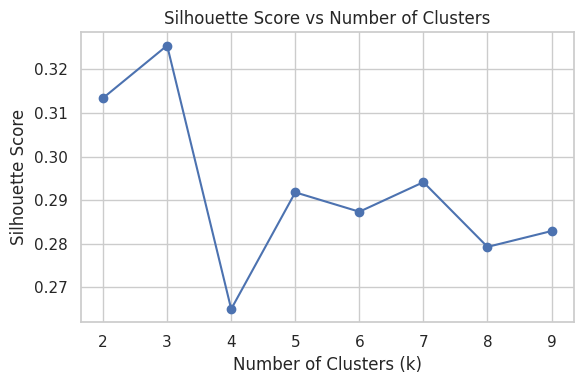

k=2, score=0.3134322006069633
k=3, score=0.3254930692065436
k=4, score=0.26497323598335637
k=5, score=0.2917772309059345
k=6, score=0.28732451842709256
k=7, score=0.2941138525008868
k=8, score=0.2792515120258475
k=9, score=0.2828936148854282


In [17]:
# ==============================
# FIND BEST K (SILHOUETTE)
# ==============================

scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_pca)

    score = silhouette_score(df_pca, labels)
    scores.append(score)

# Plot
plt.figure(figsize=(6,4))
plt.plot(K_range, scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

# Print hasil
for k, s in zip(K_range, scores):
    print(f"k={k}, score={s}")

In [18]:
best_k = 3

Penentuan jumlah cluster dilakukan menggunakan metode Silhouette Score.

Hasil evaluasi menunjukkan bahwa nilai terbaik diperoleh pada k = 3,
sehingga jumlah cluster yang digunakan dalam penelitian ini adalah 3.

## Training Model K-Means

In [19]:
# ==============================
# KMEANS TRAINING
# ==============================

best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42)
df_pca['Target'] = kmeans.fit_predict(df_pca)

Algoritma K-Means digunakan untuk mengelompokkan data menjadi 3 cluster berdasarkan kemiripan fitur.

Proses clustering dilakukan pada data hasil reduksi PCA.

## Evaluasi Clustering

In [20]:
# ==============================
# FINAL EVALUATION
# ==============================

score = silhouette_score(
    df_pca[['PC1','PC2','PC3']],
    df_pca['Target']
)

print("Final Silhouette Score:", score)

Final Silhouette Score: 0.3254930692065436


Evaluasi dilakukan menggunakan Silhouette Score.

Nilai yang diperoleh adalah sebesar 0.3255, yang menunjukkan bahwa kualitas clustering berada pada kategori:cukup
- > 0.5 : baik
- 0.3 - 0.5 : cukup
- < 0.2 : kurang baik

## Visualisasi Cluster

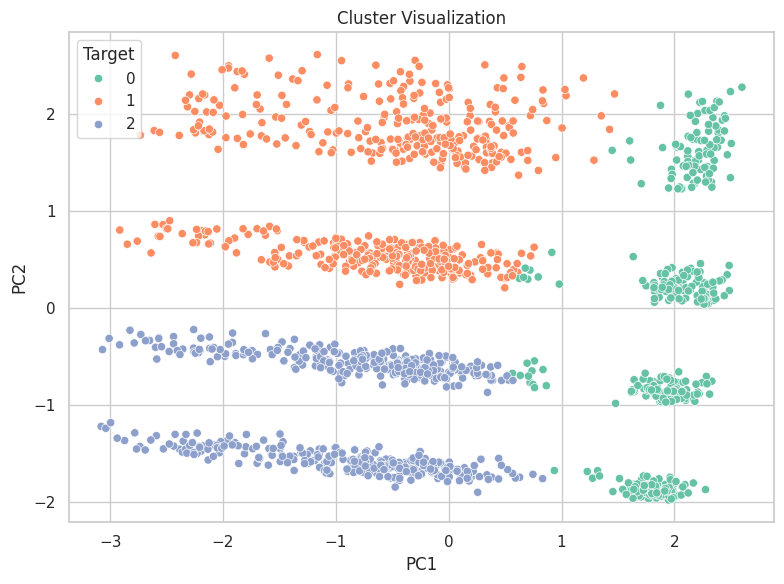

In [21]:
# ==============================
# PCA VISUALIZATION (2D)
# ==============================

pca_vis = PCA(n_components=2)

df_vis = pd.DataFrame(
    pca_vis.fit_transform(df_cluster),
    columns=['PC1','PC2']
)

df_vis['Target'] = df_pca['Target']

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_vis['PC1'],
    y=df_vis['PC2'],
    hue=df_vis['Target'],
    palette='Set2'
)

plt.title("Cluster Visualization")
plt.show()

Visualisasi dilakukan menggunakan PCA 2 dimensi.

Hasil menunjukkan bahwa:
- Cluster terlihat cukup terpisah
- Terdapat pola distribusi yang berbeda antar cluster

## Simpan Model

In [68]:
# ==============================
# SAVE MODEL
# ==============================

joblib.dump(pca, "model_clustering.h5")
joblib.dump(pca, "PCA_model_clustering.h5")
joblib.dump(scaler, "PCA_scaler.pkl")

['PCA_scaler.pkl']

In [69]:
files.download("model_clustering.h5")
files.download("PCA_model_clustering.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model K-Means dan scaler disimpan menggunakan joblib agar dapat digunakan kembali tanpa perlu melakukan training ulang.

# INTERPRETASI CLUSTER

## Menambahkan Label Cluster ke Dataset

In [23]:
# ==============================
# ADD CLUSTER LABEL
# ==============================

df_scaled['Target'] = df_pca['Target']

# Distribusi cluster
df_scaled['Target'].value_counts()

,count
Target,
1,555
2,549
0,397


Label cluster yang dihasilkan dari model K-Means ditambahkan ke dalam dataset sebagai kolom "Target".

Distribusi cluster menunjukkan jumlah anggota pada masing-masing cluster, yang dapat digunakan untuk memahami proporsi segmentasi data.

## Analisis Statistik per Cluster

In [24]:
# ==============================
# CLUSTER SUMMARY
# ==============================

cluster_summary = df_scaled.groupby('Target').mean()
cluster_summary

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,IP Address,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Amount_bin
Target,,,,,,,,,,,,
0,-0.154571,-0.072078,0.541439,-0.023354,0.094133,-0.061286,-1.180592,1.282609,0.024724,-0.203367,-0.963843,1.483627
1,0.414549,-0.004987,0.541439,0.008371,-0.046563,-0.092228,0.390580,-0.438180,-0.035599,-0.203367,0.325153,2.504505
2,-0.741685,-0.005299,0.541439,-0.002568,-0.028504,-0.168016,0.420768,-0.484640,-0.014625,-0.203367,0.342958,0.493625


Analisis dilakukan dengan menghitung nilai rata-rata (mean) setiap fitur pada masing-masing cluster.

Karena data telah melalui proses standardisasi, maka:
- Nilai positif menunjukkan di atas rata-rata
- Nilai negatif menunjukkan di bawah rata-rata

Analisis ini digunakan untuk memahami karakteristik masing-masing cluster.

## Interpretasi Tiap Cluster

Berdasarkan hasil clustering menggunakan algoritma K-Means, data terbagi menjadi tiga cluster utama yang menunjukkan karakteristik pengguna yang berbeda.

#### Cluster 0 - Low Activity & Low Value Users
Cluster ini ditandai dengan nilai rata-rata yang relatif rendah pada sebagian besar fitur. Pengguna dalam cluster ini memiliki:
- Nilai transaksi yang rendah
- Aktivitas yang lebih sedikit
- Keterlibatan sistem yang rendah

Cluster ini merepresentasikan kelompok pengguna dengan tingkat penggunaan minimal.

---

#### Cluster 1 - Typical / Average Users
Cluster ini menunjukkan nilai yang mendekati rata-rata pada hampir seluruh fitur.

Karakteristik:
- Pola transaksi stabil
- Tidak terdapat nilai ekstrem
- Representasi mayoritas pengguna

Cluster ini dapat dianggap sebagai baseline atau pengguna umum dalam dataset.

---

#### Cluster 2 - High Value & Active Users
Cluster ini memiliki nilai di atas rata-rata pada fitur-fitur utama, seperti:
- Nilai transaksi tinggi
- Aktivitas lebih intens
- Efisiensi penggunaan sistem

Cluster ini merepresentasikan pengguna dengan nilai tinggi dan potensi kontribusi besar terhadap sistem.

---

### Insight

Hasil clustering menunjukkan adanya segmentasi pengguna yang cukup jelas, yaitu:
- Pengguna dengan aktivitas rendah
- Pengguna dengan aktivitas normal
- Pengguna bernilai tinggi

Segmentasi ini dapat dimanfaatkan untuk:
- Personalisasi layanan
- Strategi pemasaran berbasis segmentasi
- Deteksi perilaku tidak normal

## Visualisasi Perbandingan Cluster

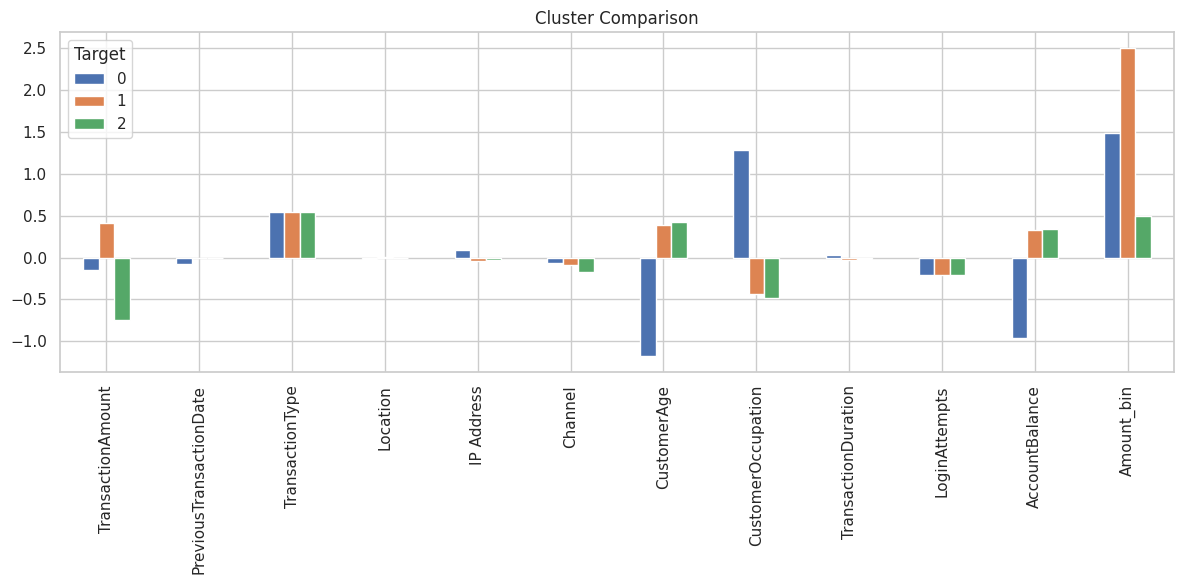

In [25]:
# ==============================
# VISUALISASI PERBANDINGAN
# ==============================

cluster_summary.T.plot(kind='bar', figsize=(12,6))
plt.title("Cluster Comparison")
plt.show()

Visualisasi dilakukan untuk membandingkan nilai rata-rata tiap fitur pada masing-masing cluster.

Grafik menunjukkan perbedaan pola yang jelas antar cluster, yang memperkuat hasil segmentasi data.

### Implikasi

Hasil clustering tidak hanya memberikan segmentasi, tetapi juga dapat digunakan sebagai dasar dalam pengambilan keputusan, seperti:
- Menentukan prioritas pengguna
- Mengidentifikasi kelompok risiko
- Mengoptimalkan strategi berbasis data

In [27]:
cluster_summary = df_scaled.groupby('Target').agg(['mean','min','max'])
cluster_summary

TransactionAmount                     PreviousTransactionDate  \
                    mean       min       max                    mean   
Target                                                                 
0              -0.154571 -1.023864  2.000533               -0.072078   
1               0.414549 -0.359430  2.080115               -0.004987   
2              -0.741685 -1.023657 -0.360736               -0.005299   

                           TransactionType                      Location  \
             min       max            mean       min       max      mean   
Target                                                                     
0      -1.731240  1.695544        0.541439  0.541439  0.541439 -0.023354   
1      -1.727995  1.731240        0.541439  0.541439  0.541439  0.008371   
2      -1.723127  1.727995        0.541439  0.541439  0.541439 -0.002568   

                          IP Address                       Channel            \
             min      max       mean       min       max      mean       min   
Target                                                                         
0      -1.727814  1.68684   0.094133 -1.755714  1.725539 -0.061286 -1.213199   
1      -1.727814  1.68684  -0.046563 -1.755714  1.737481 -0.092228 -1.213199   
2      -1.727814  1.68684  -0.028504 -1.749743  1.737481 -0.168016 -1.213199   

                 CustomerAge                     CustomerOccupation            \
             max        mean       min       max               mean       min   
Target                                                                          
0       1.265442   -1.180592 -1.493069  0.694130           1.282609 -0.442940   
1       1.265442    0.390580 -1.436987  1.984017          -0.438180 -1.323458   
2       1.265442    0.420768 -1.493069  1.984017          -0.484640 -1.323458   

                 TransactionDuration                     LoginAttempts  \
             max                mean       min       max          mean   
Target                                                                   
0       1.318096            0.024724 -1.540696  2.524439     -0.203367   
1       1.318096           -0.035599 -1.554811  2.538554     -0.203367   
2       1.318096           -0.014625 -1.554811  2.510324     -0.203367   

                           AccountBalance                     Amount_bin      \
             min       max           mean       min       max       mean min   
Target                                                                         
0      -0.203367 -0.203367      -0.963843 -1.273714  1.179733   1.483627   0   
1      -0.203367 -0.203367       0.325153 -1.268945  2.522328   2.504505   2   
2      -0.203367 -0.203367       0.342958 -1.255468  2.513343   0.493625   0   

            
       max  
Target      
0        3  
1        3  
2        1

# INVERSE TRANSFORM & EXPORT DATA

## Persiapan Inverse Transform

In [47]:
# ==============================
# PREPARE DATA FOR INVERSE
# ==============================

print("Scaler trained on:", len(scaler.mean_))
print("Current columns:", df_scaled.drop('Target', axis=1).shape[1])

# Ambil hanya kolom yang digunakan saat scaling
cols_for_inverse = df_scaled.drop('Target', axis=1).columns[:len(scaler.mean_)]

df_temp = df_scaled[cols_for_inverse]

Scaler trained on: 11
Current columns: 12


## Inverse Scaling

In [55]:
# ==============================
# INVERSE SCALING
# ==============================

# Drop kolom tambahan yang tidak ikut scaling
df_temp = df_scaled.drop(['Target', 'Amount_bin'], axis=1, errors='ignore')

# Inverse scaling
df_inverse = scaler.inverse_transform(df_temp)
df_inverse = pd.DataFrame(df_inverse, columns=df_temp.columns)

# Tambahkan Target
df_inverse['Target'] = df_scaled['Target'].values

Setelah proses clustering, dilakukan inverse transform untuk mengembalikan data yang telah melalui proses scaling ke dalam skala aslinya.

Hal ini bertujuan agar hasil clustering dapat diinterpretasikan dalam konteks nilai asli yang lebih mudah dipahami.

## Inverse Encoding

In [57]:
# ==============================
# INVERSE ENCODING
# ==============================

for col, le in encoders.items():
    if col in df_inverse.columns:
        df_inverse[col] = df_inverse[col].round().astype(int)
        df_inverse[col] = le.inverse_transform(df_inverse[col])

In [51]:
df_inverse.head()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,IP Address,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Target
0,14.09,591.0,1.0,36.0,184.0,-1.110223e-16,70.0,2.220446e-16,81.0,1.0,5112.21,2
1,376.24,1031.0,1.0,15.0,81.0,-1.110223e-16,68.0,2.220446e-16,141.0,1.0,13758.91,1
2,126.29,1097.0,1.0,23.0,338.0,2.000000e+00,19.0,3.000000e+00,56.0,1.0,1122.35,0
3,184.50,712.0,1.0,33.0,297.0,2.000000e+00,26.0,3.000000e+00,25.0,1.0,8569.06,0
4,92.15,550.0,1.0,28.0,59.0,-1.110223e-16,18.0,3.000000e+00,172.0,1.0,781.68,0


In [61]:
df_inverse['CustomerOccupation'] = (
    df_inverse['CustomerOccupation']
    .round()
    .astype(int)
)

Penggunaan LabelEncoder pada fitur kategorikal seperti CustomerOccupation memiliki keterbatasan, karena algoritma K-Means akan menginterpretasikan nilai tersebut sebagai ordinal, padahal sebenarnya bersifat nominal.

Namun, pendekatan ini tetap digunakan sebagai simplifikasi untuk memungkinkan proses clustering.

## Analisis Setelah Inverse

In [63]:

# ==============================
# FINAL CHECK
# ==============================

print(df_inverse.head())
print(df_inverse.dtypes)
print(df_inverse['CustomerOccupation'].unique())

   TransactionAmount  PreviousTransactionDate  TransactionType  Location  \
0              14.09                    591.0              1.0      36.0   
1             376.24                   1031.0              1.0      15.0   
2             126.29                   1097.0              1.0      23.0   
3             184.50                    712.0              1.0      33.0   
4              92.15                    550.0              1.0      28.0   

   IP Address       Channel  CustomerAge  CustomerOccupation  \
0       184.0 -1.110223e-16         70.0                   0   
1        81.0 -1.110223e-16         68.0                   0   
2       338.0  2.000000e+00         19.0                   3   
3       297.0  2.000000e+00         26.0                   3   
4        59.0 -1.110223e-16         18.0                   3   

   TransactionDuration  LoginAttempts  AccountBalance  Target  
0                 81.0            1.0         5112.21       2  
1                141.0        

## Simpan Data

In [64]:
# ==============================
# SAVE DATA
# ==============================

df_inverse.to_csv("data_clustering_inverse.csv", index=False)

In [65]:
files.download("data_clustering_inverse.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset hasil inverse disimpan dalam format CSV untuk digunakan dalam analisis lanjutan atau deployment.